# Projeto Sprint 11

## 1.- Introdução ao dataset

### 1.1 - Importação bibliotecas

In [1]:
# pacotes necessários para adequado estudo
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re
from scipy import stats as st
import math
from statsmodels.stats.proportion import proportions_ztest

### 1.2 - Leitura tabela

In [2]:
# leitura arquivo CSV
logs = pd.read_csv('..\dataset\logs_exp_us.csv', sep='\t')

### 1.3 - Primeiras Impressões

In [3]:
# descoberta primeiras linhas dataframe
logs.head()

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


In [4]:
# descoberta informações dataframe
logs.info()

<class 'pandas.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype
---  ------          --------------   -----
 0   EventName       244126 non-null  str  
 1   DeviceIDHash    244126 non-null  int64
 2   EventTimestamp  244126 non-null  int64
 3   ExpId           244126 non-null  int64
dtypes: int64(3), str(1)
memory usage: 7.5 MB


In [5]:
# descoberta detalhes dataframe
logs.describe()

,DeviceIDHash,EventTimestamp,ExpId
count,2.441260e+05,2.441260e+05,244126.000000
mean,4.627568e+18,1.564914e+09,247.022296
std,2.642425e+18,1.771343e+05,0.824434
min,6.888747e+15,1.564030e+09,246.000000
25%,2.372212e+18,1.564757e+09,246.000000
50%,4.623192e+18,1.564919e+09,247.000000
75%,6.932517e+18,1.565075e+09,248.000000
max,9.222603e+18,1.565213e+09,248.000000


* Não foi constatado a presença de valores ausentes.

* A nomenclatura das colunas pode ser ajustada.

* Alguns tipos de dados nas colunas também.

## 2. Pré Processamento de Dados

### 2.1 - Nomenclatura de colunas

In [6]:
# criação função snake_case
def snake_case(columns_list):
    snake_columns = []
    for col in columns_list:
        # underscore antes de maiúsculas
        s1 = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', col)
        # acrônimos
        s2 = re.sub('([a-z0-9])([A-Z])', r'\1_\2', s1)
        snake_columns.append(s2.lower())
    return snake_columns

In [7]:
# aplicação função
logs.columns = snake_case(logs.columns)
logs.columns

Index(['event_name', 'device_id_hash', 'event_timestamp', 'exp_id'], dtype='str')

### 2.2 - Ajuste coluna obj

In [8]:
# ajuste função
def snake_case(entry):
  s1 = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', entry)
  s2 = re.sub('([a-z0-9])([A-Z])', r'\1_\2', s1)
  return s2.lower()

In [9]:
# aplicação função
logs['event_name'] = logs['event_name'].apply(snake_case)
logs['event_name']

0                main_screen_appear
1                main_screen_appear
2         payment_screen_successful
3                cart_screen_appear
4         payment_screen_successful
                    ...            
244121           main_screen_appear
244122           main_screen_appear
244123           main_screen_appear
244124           main_screen_appear
244125         offers_screen_appear
Name: event_name, Length: 244126, dtype: str

### 2.3 - Correção tipo de dado

In [10]:
# coluna event_time_stamp
logs['event_timestamp'] = pd.to_datetime(logs['event_timestamp'], unit='s')

### 2.4 - Criação novas colunas

In [11]:
# coluna data
logs['event_date'] = logs['event_timestamp'].dt.date

### 2.5 - Checagem ausentes

In [12]:
# contagem ausentes por coluba
logs.isna().sum()

event_name         0
device_id_hash     0
event_timestamp    0
exp_id             0
event_date         0
dtype: int64

### 2.6 - Chegacagem duplicados

In [13]:
# soma valores duplicados
logs.duplicated().sum()

np.int64(413)

In [14]:
#  eliminação duplicados
logs = logs.drop_duplicates().reset_index(drop=True)

## 3. - Verificação de dados

### 3.1 - Quantos eventos ficam nos registros?

In [15]:
# ordenação dataframe com base cronológica de atividades
logs = logs.sort_values(by=['event_timestamp']).reset_index(drop=True)

In [16]:
# descoberta quantidade de eventos
n_events = logs.shape[0]
print(f'A quantidade de eventos registrados é {n_events}.')

A quantidade de eventos registrados é 243713.


### 3.2 - Quantos usuários ficam nos registros?

In [17]:
# descoberta quantidade de usuários
n_users = logs['device_id_hash'].nunique()
print(f'A quantidade de usuários registradas é {n_users}.')

A quantidade de usuários registradas é 7551.


### 3.3 - Qual é o número médio de eventos por usuário?

In [18]:
# descoberta número médio de eventos por usuário
average_events_per_user = n_events / n_users
print(f'Cada usuário tem em média {average_events_per_user:.1f} eventos.')

Cada usuário tem em média 32.3 eventos.


### 3.4 - Qual é o período de tempo que os dados cobrem? Encontre as datas máxima e mínima. Desenhe um histograma por data e hora. Você pode ter certeza de que possui os dados igualmente completos para todo o período? Os eventos mais antigos podem acabar aparecendo nos diários de alguns usuários por motivos técnicos, e isso pode distorcer o quadro geral. Encontre o momento em que os dados começam a ser completos e ignore a seção anterior. Qual período os dados realmente representam?

In [21]:
# descoberta datas máximas e mínimas
print(f"O período de tempo coberto pelos dados vai de {logs['event_date'].min()} até {logs['event_date'].max()}.")

O período de tempo coberto pelos dados vai de 2019-07-25 até 2019-08-07.


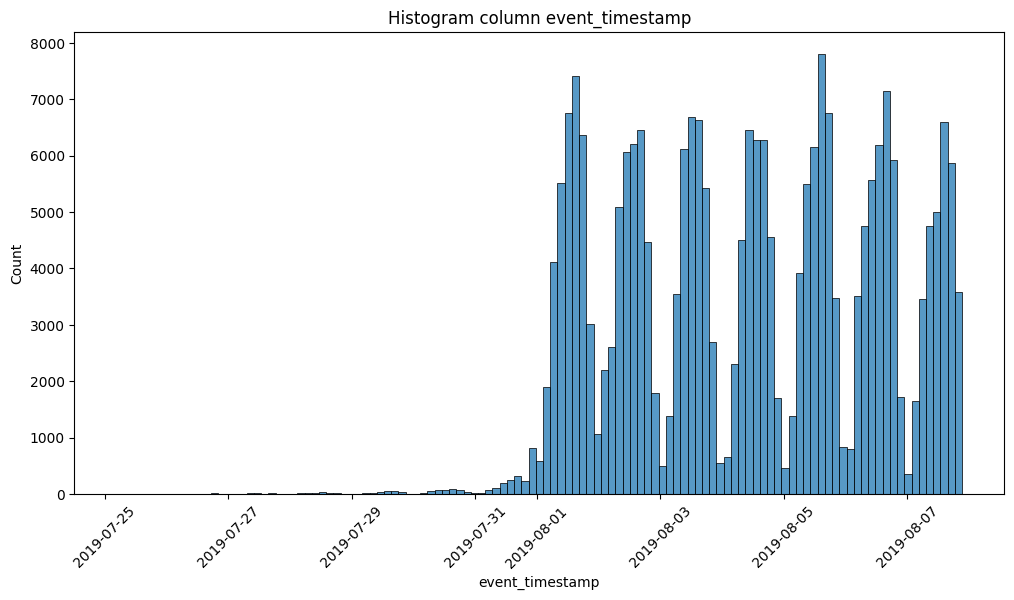

In [22]:
# criação histograma
plt.figure(figsize=(12,6))
sns.histplot(data=logs['event_timestamp'])
plt.title('Histogram column event_timestamp')
plt.xticks(rotation=45)
plt.show()

Os dados abragem 14 dias, contudo os registros da primeira semana parecem ser  incompletos.

In [23]:
# novo dataframe com filtro de datas
logs_filtered = logs[logs['event_timestamp'] >= pd.Timestamp('2019-08-01')].reset_index(drop=True)
logs_filtered.head()

,event_name,device_id_hash,event_timestamp,exp_id,event_date
0,tutorial,3737462046622621720,2019-08-01 00:07:28,246,2019-08-01
1,main_screen_appear,3737462046622621720,2019-08-01 00:08:00,246,2019-08-01
2,main_screen_appear,3737462046622621720,2019-08-01 00:08:55,246,2019-08-01
3,offers_screen_appear,3737462046622621720,2019-08-01 00:08:58,246,2019-08-01
4,main_screen_appear,1433840883824088890,2019-08-01 00:08:59,247,2019-08-01


In [24]:
print(f"O período de tempo coberto pelos dados filtrados vai de {logs_filtered['event_date'].min()} até {logs_filtered['event_date'].max()}.")

O período de tempo coberto pelos dados filtrados vai de 2019-08-01 até 2019-08-07.


### 3.5 - Você perdeu muitos eventos e usuários ao excluir os dados mais antigos?

In [25]:
# cálculos de diferença entre dfs
n_events_filtered = logs_filtered.shape[0]
n_users_filtered = logs_filtered['device_id_hash'].nunique()

n_events_dif = n_events_filtered- n_events
n_users_dif = n_users_filtered - n_users

print(f'A diferença no número de eventos após o filtro de datas é {n_events_dif} ({n_events_dif * 100 / n_events:.2f}%).')
print(f'\nA diferença no número de usuários após o filtro de datas é {n_users_dif} ({n_users_dif * 100 / n_users:.2f}%).')

A diferença no número de eventos após o filtro de datas é -2826 (-1.16%).

A diferença no número de usuários após o filtro de datas é -17 (-0.23%).


### 3.6 - Certifique-se de ter usuários de todos os três grupos experimentais.

In [26]:
# contagem grupos experimentais
logs_filtered['exp_id'].value_counts()

exp_id
248    84563
246    79302
247    77022
Name: count, dtype: int64

No princípio haviam registros de 243713 eventos provenientes de 7551 usuários, num período de tempo entre 25/07/2019 - 07/08/2019 (14 dias).


Contudo, os dados referentes à primeira semana pareciam incompletos, e foi realizado um filtro para que apenas os dados da segunda semana fossem considerados 01/08/2019 - 07/08/2019. A perda de dados foi pequena:
* Número de eventos após o filtro de datas é -2826 (-1.16%).
* Número de usuários após o filtro de datas é -17 (-0.23%).

## 4. - Funil de eventos

### 4.1 - Veja quais eventos estão nos diários e sua frequência de ocorrência. Classifique-os por frequência.

In [27]:
# criação objeto eventos e frequência
logs_funnel = logs_filtered['event_name'].value_counts().reset_index().rename(columns={'event_name': 'event_name', 'count': 'events'})
logs_funnel

,event_name,events
0,main_screen_appear,117328
1,offers_screen_appear,46333
2,cart_screen_appear,42303
3,payment_screen_successful,33918
4,tutorial,1005


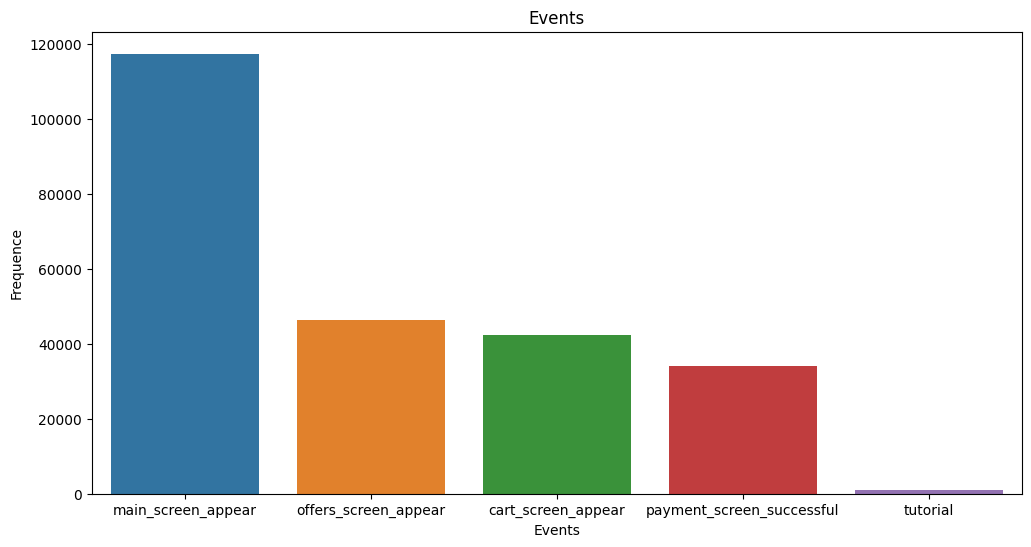

In [28]:
# criação gráfico
plt.figure(figsize=(12,6))
sns.barplot(data=logs_funnel, x='event_name', y='events', hue='event_name')
plt.title('Events')
plt.xlabel('Events')
plt.ylabel('Frequence')
plt.show()

Os eventos mais frequentes são:
 * Main_Screen_Appear,
 * Offers_Screen_Appear,
 * Cart_Screen_Appear,
 * Payment_Screen_Succesful
 * Tutorial

### 4.2 - Encontre o número de usuários que executaram cada uma dessas ações. Ordene os eventos pelo número de usuários. Calcule a proporção de usuários que executaram a ação pelo menos uma vez.

In [29]:
# agrupamento usuários por evento
users_per_event = logs_filtered.groupby('event_name')['device_id_hash'].nunique()
users_per_event

event_name
cart_screen_appear           3734
main_screen_appear           7419
offers_screen_appear         4593
payment_screen_successful    3539
tutorial                      840
Name: device_id_hash, dtype: int64

In [30]:
# união ao df funnels
logs_funnel = logs_funnel.merge(users_per_event, on='event_name').rename(columns={'event_name': 'event_name', 'events': 'events', 'device_id_hash': 'users'})
logs_funnel

,event_name,events,users
0,main_screen_appear,117328,7419
1,offers_screen_appear,46333,4593
2,cart_screen_appear,42303,3734
3,payment_screen_successful,33918,3539
4,tutorial,1005,840


In [31]:
# criação coluna proporção de usuários que executaram a ação pelo menos uma vez
logs_funnel['p_users_once'] = (logs_funnel['users'] / n_users_filtered).round(2)
logs_funnel

,event_name,events,users,p_users_once
0,main_screen_appear,117328,7419,0.98
1,offers_screen_appear,46333,4593,0.61
2,cart_screen_appear,42303,3734,0.50
3,payment_screen_successful,33918,3539,0.47
4,tutorial,1005,840,0.11


### 4.3 - Em que ordem você acha que as ações ocorreram? Todos elas fazem parte de uma única sequência? Você não precisa levá-las em consideração ao calcular o funil.

A sequência esperada de eventos é:

Tutorial -> Main_Screen_Appear -> Offers_Screen_Appear -> Cart_Screen_Appear -> Payment_Screen_Successful.

Contudo, a única etapa opcional é Tutorial, motivo qual possui o menor número de atividade de usuários.

### 4.4 - Use o funil de eventos para encontrar a parcela de usuários que passam de uma etapa para a próxima (por exemplo, para a sequência de eventos A → B → C, calcule a proporção de usuários na etapa B para o número de usuários na etapa A e a proporção de usuários na etapa C para o número na etapa B).

In [32]:
# eliminação linha tutorial
logs_funnel = logs_funnel.drop(index=4)
logs_funnel

,event_name,events,users,p_users_once
0,main_screen_appear,117328,7419,0.98
1,offers_screen_appear,46333,4593,0.61
2,cart_screen_appear,42303,3734,0.50
3,payment_screen_successful,33918,3539,0.47


In [33]:
# criação coluna user conversion
logs_funnel['user_conversion_per_event'] = logs_funnel['users'] / logs_funnel['users'].shift(1)
logs_funnel

,event_name,events,users,p_users_once,user_conversion_per_event
0,main_screen_appear,117328,7419,0.98,NaN
1,offers_screen_appear,46333,4593,0.61,0.619086
2,cart_screen_appear,42303,3734,0.50,0.812976
3,payment_screen_successful,33918,3539,0.47,0.947777


In [34]:
# preenchimento NaN conversão do passo 1 sobre total de usuários
logs_funnel['user_conversion_per_event'] = logs_funnel['user_conversion_per_event'].fillna(logs_funnel['users'][0] / n_users_filtered)
logs_funnel

,event_name,events,users,p_users_once,user_conversion_per_event
0,main_screen_appear,117328,7419,0.98,0.984736
1,offers_screen_appear,46333,4593,0.61,0.619086
2,cart_screen_appear,42303,3734,0.50,0.812976
3,payment_screen_successful,33918,3539,0.47,0.947777


In [35]:
# arredondamento coluna user_conversion
logs_funnel['user_conversion_per_event'] = logs_funnel['user_conversion_per_event'].round(2)
logs_funnel

,event_name,events,users,p_users_once,user_conversion_per_event
0,main_screen_appear,117328,7419,0.98,0.98
1,offers_screen_appear,46333,4593,0.61,0.62
2,cart_screen_appear,42303,3734,0.50,0.81
3,payment_screen_successful,33918,3539,0.47,0.95


### 4.5 - Em qual fase você perde mais usuários?

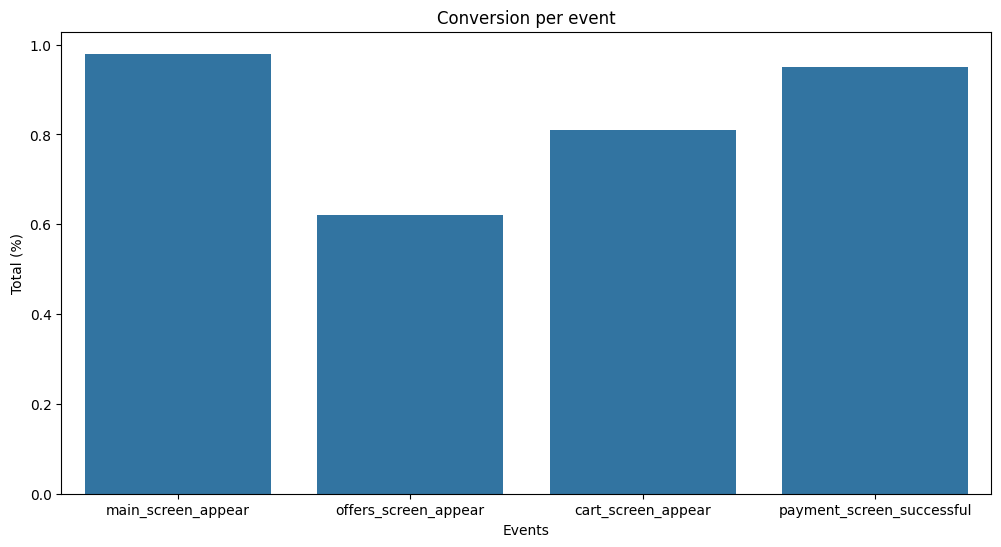

In [36]:
# criação gráfico
plt.figure(figsize=(12,6))
sns.barplot(data=logs_funnel, x='event_name', y='user_conversion_per_event')
plt.title('Conversion per event')
plt.xlabel('Events')
plt.ylabel('Total (%)')
plt.show()

A fase em que houve maior perca de usuários foi a etapa 2 - Offers_Screen_Appear, com cerca de 62% dos usuários da etapa anterior (Main_Screen_Appear) prosseguindo com o processo esperado.

### 4.6 - Qual é a parcela de usuários que faz o caminho inteiro, desde o primeiro evento até o pagamento?

In [37]:
logs_funnel

,event_name,events,users,p_users_once,user_conversion_per_event
0,main_screen_appear,117328,7419,0.98,0.98
1,offers_screen_appear,46333,4593,0.61,0.62
2,cart_screen_appear,42303,3734,0.50,0.81
3,payment_screen_successful,33918,3539,0.47,0.95


In [38]:
# criação coluna conversão acumulada
logs_funnel['acumulated_conversion'] = (logs_funnel['users'] / logs_funnel.loc[0, 'users']).round(2)

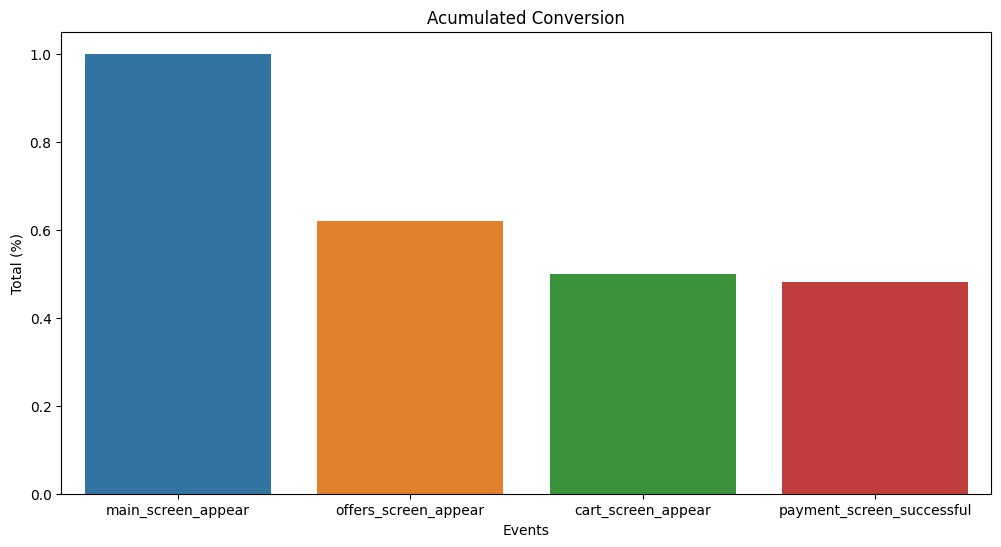

In [39]:
# criação gráfico
plt.figure(figsize=(12,6))
sns.barplot(data=logs_funnel, x='event_name', y='acumulated_conversion', hue='event_name')
plt.title('Acumulated Conversion')
plt.xlabel('Events')
plt.ylabel('Total (%)')
plt.show()

In [41]:
# mensagem
print(f"A parcela de usuários que percorreu todo o caminho esperado foi de aproximadamente {n_users_filtered / 1 * logs_funnel.loc[3, 'acumulated_conversion']:.1f} ({logs_funnel.loc[3, 'acumulated_conversion'] * 100:.0f}%).")

A parcela de usuários que percorreu todo o caminho esperado foi de aproximadamente 3616.3 (48%).


## 5. - Resultados do experimento

### 5.1 - Quantos usuários há em cada grupo?

In [42]:
# descoberta usuários por grupo
users_per_group = logs_filtered.groupby('exp_id')['device_id_hash'].nunique()
users_per_group

exp_id
246    2484
247    2513
248    2537
Name: device_id_hash, dtype: int64

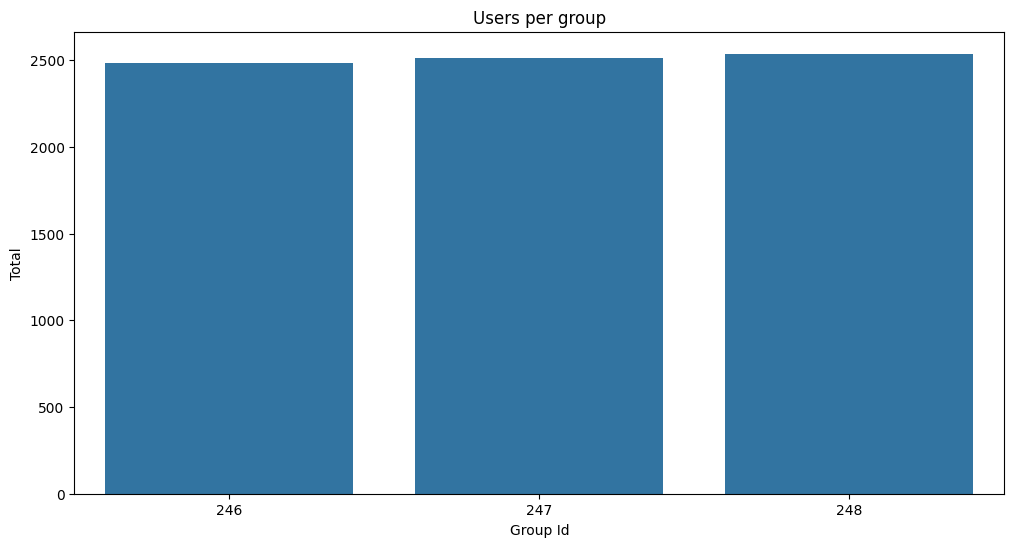

In [43]:
# criação gráfico
plt.figure(figsize=[12,6])
sns.barplot(users_per_group)
plt.title('Users per group')
plt.xlabel('Group Id')
plt.ylabel('Total')
plt.show()

* Grupo 246 -> 2484 usuários.

* Grupo 247 -> 2513 usuários.

* Grupo 248 -> 2537 usuários.

### 5.2 - Temos dois grupos de controle no teste A/A, no qual verificamos nossos mecanismos e cálculos. Veja se há uma diferença estatisticamente significativa entre as amostragens 246 e 247.

In [44]:
# cálculo proporções
x = [users_per_group.loc[246], users_per_group.loc[247]]
n = [users_per_group.sum(), users_per_group.sum()]

stat, pval = proportions_ztest(x, n)

In [45]:
# nível significância
alpha = 0.05

In [46]:
# mensagem
if pval < alpha:
    print('Há evidência de diferença estatisticamente significativa entre os grupos 246 e 247.')
else:
    print('Não há evidência de diferença estatisticamente significativa entre os grupos 246 e 247.')

Não há evidência de diferença estatisticamente significativa entre os grupos 246 e 247.


### 5.3 - Selecione o evento mais popular. Em cada um dos grupos de controle, encontre o número de usuários que realizaram essa ação. Encontre a proporção deles. Verifique se a diferença entre os grupos é estatisticamente significativa. Repita o procedimento para todos os outros eventos (economizará tempo se você criar uma função especial para este teste). Você pode confirmar se os grupos foram divididos corretamente?

#### 5.3.1 - Criação novo funil

In [47]:
# criação novo funil com grupos
new_funnel = logs_filtered[['exp_id', 'event_name']].value_counts().reset_index()
new_funnel

,exp_id,event_name,count
0,248,main_screen_appear,40562
1,247,main_screen_appear,39090
2,246,main_screen_appear,37676
3,248,offers_screen_appear,16387
4,247,offers_screen_appear,15179
5,248,cart_screen_appear,15179
6,246,offers_screen_appear,14767
7,246,cart_screen_appear,14690
8,247,cart_screen_appear,12434
9,248,payment_screen_successful,12085


In [48]:
# agregação dados usuários
users_per_groups_per_events = logs_filtered.groupby(['exp_id', 'event_name'])['device_id_hash'].nunique().reset_index()
users_per_groups_per_events

,exp_id,event_name,device_id_hash
0,246,cart_screen_appear,1266
1,246,main_screen_appear,2450
2,246,offers_screen_appear,1542
3,246,payment_screen_successful,1200
4,246,tutorial,278
5,247,cart_screen_appear,1238
6,247,main_screen_appear,2476
7,247,offers_screen_appear,1520
8,247,payment_screen_successful,1158
9,247,tutorial,283


In [49]:
# união funil com usuários
new_funnel = new_funnel.merge(users_per_groups_per_events, on=['exp_id', 'event_name'], how='left').rename(columns={'exp_id': 'group', 'event_name': 'description', 'count': 'events', 'device_id_hash': 'users'})
new_funnel

,group,description,events,users
0,248,main_screen_appear,40562,2493
1,247,main_screen_appear,39090,2476
2,246,main_screen_appear,37676,2450
3,248,offers_screen_appear,16387,1531
4,247,offers_screen_appear,15179,1520
5,248,cart_screen_appear,15179,1230
6,246,offers_screen_appear,14767,1542
7,246,cart_screen_appear,14690,1266
8,247,cart_screen_appear,12434,1238
9,248,payment_screen_successful,12085,1181


In [50]:
# criação função cálculo proporção
def user_proportion_once (row):
  group = row['group']
  description = row['description']
  users = row['users']
  if group == 246:
    return (users / users_per_group.loc[group]).round(2)
  elif group == 247:
    return (users / users_per_group.loc[group]).round(2)
  else:
    return (users / users_per_group.loc[group]).round(2)

# aplicação função
new_funnel['p_users_once'] = new_funnel.apply(user_proportion_once, axis=1)
new_funnel#(new_funnel['users'] / users_per_group).round(2)

,group,description,events,users,p_users_once
0,248,main_screen_appear,40562,2493,0.98
1,247,main_screen_appear,39090,2476,0.99
2,246,main_screen_appear,37676,2450,0.99
3,248,offers_screen_appear,16387,1531,0.60
4,247,offers_screen_appear,15179,1520,0.60
5,248,cart_screen_appear,15179,1230,0.48
6,246,offers_screen_appear,14767,1542,0.62
7,246,cart_screen_appear,14690,1266,0.51
8,247,cart_screen_appear,12434,1238,0.49
9,248,payment_screen_successful,12085,1181,0.47


#### 5.3.2 - Teste estatístico grupo de controle

In [51]:
# criação função
def z_test_per_event(df, event):
    # proporções
    x = [
        df.loc[(df['exp_id'] == 246) & (df['event_name'] == event), 'device_id_hash'].nunique(),
        df.loc[(df['exp_id'] == 247) & (df['event_name'] == event), 'device_id_hash'].nunique()
    ]

    # totais
    n = [
        users_per_group.loc[246],
        users_per_group.loc[247]
    ]

    stat, pval = proportions_ztest(x, n)
    return pval

In [52]:
# aplicação função
results = []

for event in logs_filtered['event_name'].unique():
    pval = z_test_per_event(logs_filtered, event)
    results.append({
        'event': event,
        'p_value': pval,
        'significant_5pct': 'Diferença estatísticamente significativa ' if pval < 0.05 else 'Não há evidência de diferença estatísticamente significativa.'
    })

df_results = pd.DataFrame(results)
df_results

,event,p_value,significant_5pct
0,tutorial,0.937700,Não há evidência de diferença estatísticamente...
1,main_screen_appear,0.757060,Não há evidência de diferença estatísticamente...
2,offers_screen_appear,0.248095,Não há evidência de diferença estatísticamente...
3,cart_screen_appear,0.228834,Não há evidência de diferença estatísticamente...
4,payment_screen_successful,0.114567,Não há evidência de diferença estatísticamente...


Para os teste realizados entre os dois grupos de controle A (246 e 247), não foi encontrada evidência de diferença estatísticamente significativa entre os dois grupos de usuários para cada evento.

### 5.4 - Faça a mesma coisa para o grupo com fontes alteradas. Compare os resultados com os de cada um dos grupos de controle para cada evento isoladamente. Compare os resultados com os resultados combinados para os grupos de controle. Quais conclusões você pode tirar do experimento?

#### 5.4.1 - Testes entre grupo b e grupos de controle combinados e eventos isolados

In [53]:
# criação função
def z_test_per_event_2(df):
  answers = []
  events = df['event_name'].unique()
  control_groups = [246, 247]
  group_b = 248
  alpha = 0.05

  for event in events:
    x = [df.loc[(df['exp_id'].isin(control_groups)) & (df['event_name'] == event), 'device_id_hash'].nunique(),
        df.loc[(df['exp_id'] == group_b) & (df['event_name'] == event), 'device_id_hash'].nunique()]
    n = [users_per_group.loc[246] + users_per_group.loc[247], users_per_group.loc[248]]

    stat, pval = proportions_ztest(x, n)

    if pval > alpha:
      interpretation = 'Não hvidência de diferença estatísticamente significativa entre os dois grupos.'
    else:
      interpretation = 'Há evidência de diferença estatísticamente significativa entre os dois grupos.'

    answers.append({'event': event, 'p_value': pval, 'interpretation': interpretation})

  return pd.DataFrame(answers)

In [54]:
# aplicação função
df_answers_2 = z_test_per_event_2(logs_filtered)
df_answers_2

,event,p_value,interpretation
0,tutorial,0.764862,Não hvidência de diferença estatísticamente si...
1,main_screen_appear,0.294245,Não hvidência de diferença estatísticamente si...
2,offers_screen_appear,0.434255,Não hvidência de diferença estatísticamente si...
3,cart_screen_appear,0.181759,Não hvidência de diferença estatísticamente si...
4,payment_screen_successful,0.600429,Não hvidência de diferença estatísticamente si...


Para todos os testes realizados entre os dois grupos de controle A combinados e o grupo B, em nenhum deles há evidência de diferença estatísticamente significativa entre os dois grupos de usuários.

#### 5.4.2 - Testes entre grupo b e grupos de controle separados e eventos isolados

In [55]:
# criação função
def z_test_per_event_3(df):
  answers = []
  events = df['event_name'].unique()
  control_groups = [246, 247]
  group_b = 248
  alpha = 0.05

  for event in events:
    for group in control_groups:
      x = [df.loc[(df['exp_id'] == group) & (df['event_name'] == event), 'device_id_hash'].nunique(),
           df.loc[(df['exp_id'] == group_b) & (df['event_name'] == event), 'device_id_hash'].nunique()]
      n = [users_per_group.loc[group], users_per_group.loc[group_b]]

      stat, pval = proportions_ztest(x, n)

      if pval > alpha:
        interpretation = 'Não há evidência de diferença estatísticamente significativa entre os dois grupos de usuários.'
      else:
        interpretation = 'Há evidência de diferença estatísticamente significativa entre os dois grupos de usuários.'

      answers.append({'event': event, 'comparison': f'{group} vs {group_b}', 'p_value': pval, 'interpretation': interpretation})

  return pd.DataFrame(answers)

In [56]:
df_answers_3 = z_test_per_event_3(logs_filtered)
df_answers_3

,event,comparison,p_value,interpretation
0,tutorial,246 vs 248,0.826429,Não há evidência de diferença estatísticamente...
1,tutorial,247 vs 248,0.765324,Não há evidência de diferença estatísticamente...
2,main_screen_appear,246 vs 248,0.294972,Não há evidência de diferença estatísticamente...
3,main_screen_appear,247 vs 248,0.458705,Não há evidência de diferença estatísticamente...
4,offers_screen_appear,246 vs 248,0.208362,Não há evidência de diferença estatísticamente...
5,offers_screen_appear,247 vs 248,0.919782,Não há evidência de diferença estatísticamente...
6,cart_screen_appear,246 vs 248,0.078429,Não há evidência de diferença estatísticamente...
7,cart_screen_appear,247 vs 248,0.578620,Não há evidência de diferença estatísticamente...
8,payment_screen_successful,246 vs 248,0.212255,Não há evidência de diferença estatísticamente...
9,payment_screen_successful,247 vs 248,0.737342,Não há evidência de diferença estatísticamente...


Para todos os testes realizados entre os dois grupos de controle A e o grupo B, em nenhum deles há evidência de diferença estatísticamente significativa entre os dois grupos de usuários.

### 5.5 - Qual nível de significância você definiu para testar as hipóteses estatísticas mencionadas acima? Calcule quantos testes de hipóteses estatísticas você realizou. Com um nível de significância estatística de 0,1, um de cada 10 resultados pode ser falso. Qual deveria ser o nível de significância? Se você quiser alterá-lo, execute as etapas anteriores novamente e verifique suas conclusões.

O nível de significância utilizado para realização dos testes estatísticos foi de 5%.

Foram realizados no último exercício 10 testes, entre grupos de teste e cada evento isolado.

A redução do nível de significância para 0.1% implica em maior possibilidade de erro tipo I - falso positivo.

Dado este contexto, a escolha pelo nível de significância em 5% é considerada equilibrada, visando reduzir a chance de conclusões incorretas.